In [1]:
import pandas as pd
import numpy as np
import neurokit2 as nk
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df_cgm = pd.read_csv('data/bigidea/001/Dexcom_001.csv')
# print(df_cgm.columns)
columns_to_keep = ['Index', 'Timestamp (YYYY-MM-DDThh:mm:ss)', 'Glucose Value (mg/dL)', 'Event Type']
columns_to_drop = [col for col in df_cgm.columns if col not in columns_to_keep]
df_cgm.drop(columns=columns_to_drop, inplace=True)
# print(df_cgm['Timestamp (YYYY-MM-DDThh:mm:ss)'].unique())
# print(df_cgm.head(15))
# the first 11 rows don't have timestamps and glucose values, so we can drop them
df_cgm = df_cgm.dropna(subset=['Timestamp (YYYY-MM-DDThh:mm:ss)', 'Glucose Value (mg/dL)']).reset_index(drop=True)
print(df_cgm.head())

   Index Timestamp (YYYY-MM-DDThh:mm:ss) Event Type  Glucose Value (mg/dL)
0     13             2020-02-13 17:23:32        EGV                   61.0
1     14             2020-02-13 17:28:32        EGV                   59.0
2     15             2020-02-13 17:33:32        EGV                   58.0
3     16             2020-02-13 17:38:32        EGV                   59.0
4     17             2020-02-13 17:43:31        EGV                   63.0


In [3]:
df_ibi = pd.read_csv('data/bigidea/001/IBI_001.csv')
print(df_ibi.columns)
df_ibi.head()

Index(['datetime', ' ibi'], dtype='object')


,datetime,ibi
0,2020-02-13 15:33:22.059328,0.828163
1,2020-02-13 15:33:22.934368,0.875040
2,2020-02-13 15:34:21.593303,0.984420
3,2020-02-13 15:34:22.483969,0.890666
4,2020-02-13 15:34:23.421512,0.937543


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/neurokit2/complexity/entropy_multiscale.py:346: RuntimeWarning: invalid value encountered in scalar divide
  mse = np.trapezoid(mse) / len(mse)
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/neurokit2/complexity/optim_complexity_k.py:134: RuntimeWarning: divide by zero encountered in divide
  normalization = (n - 1) / (np.floor((n - k_subrange) / k).astype(int) * k)
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/neurokit2/complexity/optim_complexity_k.py:135: RuntimeWarning: invalid value encountered in multiply
  sets = (np.nansum(np.abs(np.diff(sig_values)), axis=1) * normalization) / k
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/neurokit2/complexity/entropy_multiscale.py:346: RuntimeWarning: invalid value encountered in scalar divide
  mse = np.trapezoid(mse) / len(mse)
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/pyth

Model Performance:
Mean Absolute Error: 7.91 mg/dL
R² Score: -0.08


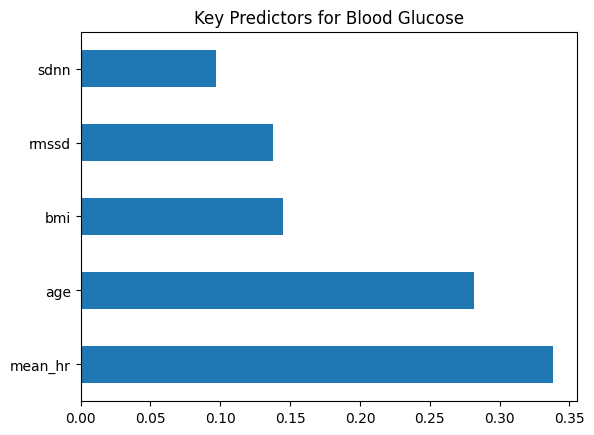

In [4]:


# 1. GENERATE SYNTHETIC DATA (Mimicking a PPG wearable dataset)
def generate_poc_data(n_samples=100):
    data = []
    sampling_rate = 100
    duration = 10  # seconds per sample
    
    for i in range(n_samples):
        # Simulate a raw PPG signal
        ppg = nk.ppg_simulate(duration=duration, sampling_rate=sampling_rate, heart_rate=np.random.randint(60, 90))
        
        # Extract HRV and Morphological features using NeuroKit2
        signals, info = nk.ppg_process(ppg, sampling_rate=sampling_rate)
        hrv_metrics = nk.hrv(signals, sampling_rate=sampling_rate)
        
        # Feature Engineering: Get mean heart rate and a few HRV markers
        features = {
            'mean_hr': signals["PPG_Rate"].mean(),
            'sdnn': hrv_metrics['HRV_SDNN'].values[0],
            'rmssd': hrv_metrics['HRV_RMSSD'].values[0],
            'age': np.random.randint(20, 70),
            'bmi': np.random.uniform(18, 35)
        }
        
        # Simulate BGL: Logic is that higher HR/lower HRV often correlates with metabolic stress
        # This is simplified for the POC
        features['bgl_target'] = (features['mean_hr'] * 0.5) + (features['age'] * 0.2) + np.random.normal(70, 10)
        data.append(features)
        
    return pd.DataFrame(data)

df = generate_poc_data(100)

# 2. MACHINE LEARNING PIPELINE
# Define Features (X) and Target (y)
X = df.drop(columns=['bgl_target'])
y = df['bgl_target']

# Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and Train Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 3. EVALUATION
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Model Performance:")
print(f"Mean Absolute Error: {mae:.2f} mg/dL")
print(f"R² Score: {r2:.2f}")

# Show Feature Importance (Which signal part matters most?)
import matplotlib.pyplot as plt
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(5).plot(kind='barh')
plt.title("Key Predictors for Blood Glucose")
plt.show()


[-0.14728395 -0.09406818 -0.04148323 ...  0.68917315  0.6891728
  0.68917269]
Max value in the PPG signal: 1.8464828184138726
Min value in the PPG signal: -0.14728394531301894
Average value in the PPG signal: 0.6714308209597997


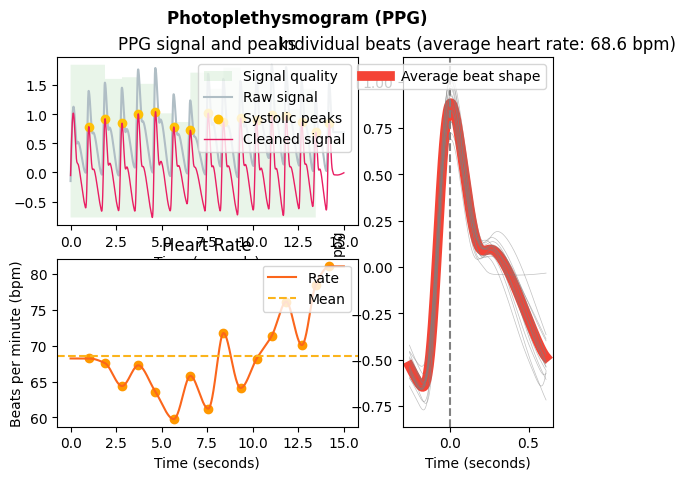

In [8]:
# Generate 15 seconds of PPG signal (recorded at 250 samples/second)
ppg = nk.ppg_simulate(duration=15, sampling_rate=250, heart_rate=70)
print(ppg)
max_value = np.max(ppg)
print(f"Max value in the PPG signal: {max_value}")
min_value = np.min(ppg)
print(f"Min value in the PPG signal: {min_value}")
avg_value = np.mean(ppg)
print(f"Average value in the PPG signal: {avg_value}")
assert len(ppg) == 15 * 250, "PPG signal length should be equal to duration * sampling_rate"
# Process it
signals, info = nk.ppg_process(ppg, sampling_rate=250)

# Visualize the processing
nk.ppg_plot(signals, info)